# Clustering Analysis

This notebook performs clustering analysis on the CC GENERAL dataset with **RobustScaler** for better outlier handling.

## Overview
- **Dataset**: CC GENERAL.csv
- **Objective**: Identify patterns and group similar data points
- **Methods**: K-Means, DBSCAN, Hierarchical Clustering
- **Scaling**: RobustScaler (robust to outliers)

## Workflow
1. **Data Loading & Exploration**
2. **RobustScaler Application** (for outlier handling)
3. **Data Preprocessing & Feature Engineering**
4. **Clustering Analysis**
5. **Model Evaluation & Visualization**
6. **Results & Insights**

---

In [1]:
# Import essential libraries for clustering analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering algorithms
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Preprocessing and metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

# Additional utilities
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('default')
sns.set_palette('husl')

print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Data Loading & Exploration

We'll start by downloading and loading the credit card dataset from Kaggle. This dataset contains customer behavior data that we'll use for clustering analysis.

### Dataset Source
- **Dataset**: CC GENERAL (Credit Card Dataset for Clustering)
- **Source**: Kaggle - arjunbhasin2013/ccdata
- **Description**: Customer data with various credit card usage patterns and behaviors

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arjunbhasin2013/ccdata")


print("Path to dataset files:", path)

Path to dataset files: C:\Users\Heka\.cache\kagglehub\datasets\arjunbhasin2013\ccdata\versions\1


In [3]:
# Load the CSV file from the downloaded path
import os
csv_file = os.path.join(path, 'CC GENERAL.csv')
df = pd.read_csv(csv_file)
print(f"Dataset loaded successfully! Shape: {df.shape}")

Dataset loaded successfully! Shape: (8950, 18)


### Initial Data Preview

Let's examine the first few rows of our dataset to understand its structure and the types of features available for clustering.

## 2. Data Preprocessing & Feature Engineering

Before performing clustering, we need to thoroughly understand our data through exploratory analysis and handle any data quality issues.

### Data Exploration Function

We'll create a comprehensive function to explore our dataset's characteristics:

In [4]:
def data_exploration(df):
    
    print(f"Show Dataset Columns:\n")
    print(df.columns)
    print(f"-------------------------\n")
    print(f"Show Dataset Shape:\n")
    print(df.shape)
    print(f"-------------------------\n")
    print(f"Show Data Description:\n")
    print(df.describe())
    print(f"-------------------------\n")
    print(f"Show Data Information:\n")
    print(df.info())
    print(f"-------------------------\n")
   

### Comprehensive Data Analysis

Now let's run our exploration function to get detailed insights about the dataset:

In [5]:
data_exploration(df)

Show Dataset Columns:

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')
-------------------------

Show Dataset Shape:

(8950, 18)
-------------------------

Show Data Description:

            BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count   8950.000000        8950.000000   8950.000000       8950.000000   
mean    1564.474828           0.877271   1003.204834        592.437371   
std     2081.531879           0.236904   2136.634782       1659.887917   
min        0.000000           0.000000      0.000000          0.000000   
25%      128.281915           0.888889     39.635000          0.000000   
50%      8

### Missing Values Analysis

Let's check for missing values in our dataset, as these need to be handled before clustering:

In [6]:
print(f"View Missing Value:\n")
print(df.isnull().sum().sort_values(ascending=False))

View Missing Value:

MINIMUM_PAYMENTS                    313
CREDIT_LIMIT                          1
CUST_ID                               0
BALANCE                               0
PRC_FULL_PAYMENT                      0
PAYMENTS                              0
PURCHASES_TRX                         0
CASH_ADVANCE_TRX                      0
CASH_ADVANCE_FREQUENCY                0
PURCHASES_INSTALLMENTS_FREQUENCY      0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_FREQUENCY                   0
CASH_ADVANCE                          0
INSTALLMENTS_PURCHASES                0
ONEOFF_PURCHASES                      0
PURCHASES                             0
BALANCE_FREQUENCY                     0
TENURE                                0
dtype: int64


### Duplicate Records Analysis

We need to check for and handle any duplicate records in our dataset:

In [7]:
def check_duplicate(df):
 print(df.duplicated().sum())


**Checking for duplicates:**

In [8]:
check_duplicate(df)

0


**Function to remove duplicates (if any):**

In [9]:
def drop_duplicate(df):
    df = df.drop_duplicates()


**Applying duplicate removal:**

In [10]:
drop_duplicate(df)

In [11]:
# Display min and max values for each numeric column
print("Min and Max Values for Each Column:")
print("="*60)

for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:  # Only for numeric columns
        min_val = df[col].min()
        max_val = df[col].max()
        print(f"{col:35} | Min: {min_val:12.2f} | Max: {max_val:12.2f}")
    else:
        print(f"{col:35} | Type: {df[col].dtype} (Non-numeric)")

print("="*60)

Min and Max Values for Each Column:
CUST_ID                             | Type: object (Non-numeric)
BALANCE                             | Min:         0.00 | Max:     19043.14
BALANCE_FREQUENCY                   | Min:         0.00 | Max:         1.00
PURCHASES                           | Min:         0.00 | Max:     49039.57
ONEOFF_PURCHASES                    | Min:         0.00 | Max:     40761.25
INSTALLMENTS_PURCHASES              | Min:         0.00 | Max:     22500.00
CASH_ADVANCE                        | Min:         0.00 | Max:     47137.21
PURCHASES_FREQUENCY                 | Min:         0.00 | Max:         1.00
ONEOFF_PURCHASES_FREQUENCY          | Min:         0.00 | Max:         1.00
PURCHASES_INSTALLMENTS_FREQUENCY    | Min:         0.00 | Max:         1.00
CASH_ADVANCE_FREQUENCY              | Min:         0.00 | Max:         1.50
CASH_ADVANCE_TRX                    | Min:         0.00 | Max:       123.00
PURCHASES_TRX                       | Min:         0.00 | Max: 

In [12]:
# Function to detect outliers using IQR
def detect_outliers_iqr(df):
    print("OUTLIER DETECTION (IQR Method)")
    print("="*60)
    for col in df.columns:
        if df[col].dtype != 'object':  
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            outliers = df[(df[col] < lower) | (df[col] > upper)]
            out_count = outliers.shape[0]
            out_percent = (out_count / df.shape[0]) * 100
            print(f"{col:<35} | Outliers: {out_count:5} ( {out_percent:5.1f}% )")

detect_outliers_iqr(df)

OUTLIER DETECTION (IQR Method)
BALANCE                             | Outliers:   695 (   7.8% )
BALANCE_FREQUENCY                   | Outliers:  1493 (  16.7% )
PURCHASES                           | Outliers:   808 (   9.0% )
ONEOFF_PURCHASES                    | Outliers:  1013 (  11.3% )
INSTALLMENTS_PURCHASES              | Outliers:   867 (   9.7% )
CASH_ADVANCE                        | Outliers:  1030 (  11.5% )
PURCHASES_FREQUENCY                 | Outliers:     0 (   0.0% )
ONEOFF_PURCHASES_FREQUENCY          | Outliers:   782 (   8.7% )
PURCHASES_INSTALLMENTS_FREQUENCY    | Outliers:     0 (   0.0% )
CASH_ADVANCE_FREQUENCY              | Outliers:   525 (   5.9% )
CASH_ADVANCE_TRX                    | Outliers:   804 (   9.0% )
PURCHASES_TRX                       | Outliers:   766 (   8.6% )
CREDIT_LIMIT                        | Outliers:   248 (   2.8% )
PAYMENTS                            | Outliers:   808 (   9.0% )
MINIMUM_PAYMENTS                    | Outliers:   841 (   9

## Missing Value Handling

Based on our analysis, we have:
- **CREDIT_LIMIT**: 1 missing value (0.01%)
- **MINIMUM_PAYMENTS**: 313 missing values (3.5%)

### Strategy:
1. **CREDIT_LIMIT**: Fill with median (single missing value)
2. **MINIMUM_PAYMENTS**: Fill with median (reasonable for financial data)

Let's implement the missing value handling:

In [13]:
from sklearn.impute import KNNImputer

    # Create a copy of the dataframe for preprocessing
    # First, remove CUST_ID column as it's not needed for analysis
df_clean = df.drop(columns=['CUST_ID'])

df_processed = df_clean.copy()


    # Handle Missing Value 
imputer = KNNImputer(n_neighbors=5)
df_processed = pd.DataFrame(
imputer.fit_transform(df_processed),
columns=df_processed.columns
    )


print("\n" + "="*50 + "\n")
print("Missing values after handling:")
print(df_processed.isnull().sum())

print(f"\nDataset shape after preprocessing: {df_processed.shape}")



Missing values after handling:
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

Dataset shape after preprocessing: (8950, 17)


## Next Steps: Feature Scaling

### Upcoming Tasks:
1. **Feature Scaling**: Standardize features for clustering algorithms
2. **Outlier Analysis**: Detect and handle outliers
3. **Correlation Analysis**: Understand feature relationships
4. **Dimensionality Reduction**: Apply PCA if needed
5. **Clustering Implementation**: K-Means, DBSCAN, Hierarchical



## Simple Skewness Detection and Fix

Quick and easy way to detect and fix skewed columns:

In [14]:
from scipy import stats
from sklearn.preprocessing import PowerTransformer
import numpy as np

# 1. Detect skewness (threshold: 1)
skewed_columns = []
print("Skewness Analysis:")
print("-" * 40)

for col in df_processed.columns:
    skew_value = stats.skew(df_processed[col])
    print(f"{col}: {skew_value:.3f}")
    threshold=1
    # If absolute skewness > 1, consider it skewed
    if abs(skew_value) > threshold:
        skewed_columns.append(col)

print(f"\nSkewed columns (|skew| > 0.5): {len(skewed_columns)}")
print(skewed_columns)

Skewness Analysis:
----------------------------------------
BALANCE: 2.393
BALANCE_FREQUENCY: -2.023
PURCHASES: 8.143
ONEOFF_PURCHASES: 10.043
INSTALLMENTS_PURCHASES: 7.298
CASH_ADVANCE: 5.166
PURCHASES_FREQUENCY: 0.060
ONEOFF_PURCHASES_FREQUENCY: 1.535
PURCHASES_INSTALLMENTS_FREQUENCY: 0.509
CASH_ADVANCE_FREQUENCY: 1.828
CASH_ADVANCE_TRX: 5.720
PURCHASES_TRX: 4.630
CREDIT_LIMIT: 1.522
PAYMENTS: 5.907
MINIMUM_PAYMENTS: 13.626
PRC_FULL_PAYMENT: 1.942
TENURE: -2.943

Skewed columns (|skew| > 0.5): 15
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'ONEOFF_PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [15]:
# 2. Fix skewness using Yeo-Johnson transformation
df_fixed = df_processed.copy()

if skewed_columns:
    print(f"\nFixing {len(skewed_columns)} skewed columns...")
    
    # Apply Yeo-Johnson transformation (works with negative values)
    transformer = PowerTransformer(method='yeo-johnson')
    df_fixed[skewed_columns] = transformer.fit_transform(df_fixed[skewed_columns])
    
    print("\nSkewness after transformation:")
    print("-" * 40)
    
    for col in skewed_columns:
        old_skew = stats.skew(df_processed[col])
        new_skew = stats.skew(df_fixed[col])
        print(f"{col}: {old_skew:.3f} → {new_skew:.3f}")
    
    print("\n✅ Skewness fixed! Data is now ready for clustering.")
else:
    print("\n✅ No skewed columns found. Data is already good for clustering!")


Fixing 15 skewed columns...

Skewness after transformation:
----------------------------------------
BALANCE: 2.393 → -0.119
BALANCE_FREQUENCY: -2.023 → -1.119
PURCHASES: 8.143 → -0.179
ONEOFF_PURCHASES: 10.043 → 0.115
INSTALLMENTS_PURCHASES: 7.298 → -0.015
CASH_ADVANCE: 5.166 → 0.188
ONEOFF_PURCHASES_FREQUENCY: 1.535 → 0.541
CASH_ADVANCE_FREQUENCY: 1.828 → 0.506
CASH_ADVANCE_TRX: 5.720 → 0.393
PURCHASES_TRX: 4.630 → 0.006
CREDIT_LIMIT: 1.522 → -0.010
PAYMENTS: 5.907 → 0.125
MINIMUM_PAYMENTS: 13.626 → -0.028
PRC_FULL_PAYMENT: 1.942 → 0.964
TENURE: -2.943 → -1.971

✅ Skewness fixed! Data is now ready for clustering.


## Simple PCA

Quick dimensionality reduction:

In [16]:
from sklearn.decomposition import PCA

# Simple PCA - keep 95% of variance
pca = PCA(n_components=2, random_state=24)  # Keep 95% variance
X_pca = pca.fit_transform(df_fixed)  # استخدام البيانات المقيسة بـ RobustScaler

print(f"Original features: {df_fixed.shape[1]}")
print(f"PCA components: {X_pca.shape[1]}")
print(f"Variance kept: {pca.explained_variance_ratio_.sum():.3f} (58.1%)")
print(f"\n✅ PCA done with RobustScaler data! Reduced from {df_fixed.shape[1]} to {X_pca.shape[1]} features")

Original features: 17
PCA components: 2
Variance kept: 0.579 (58.1%)

✅ PCA done with RobustScaler data! Reduced from 17 to 2 features


c:\Users\Heka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Heka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Heka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Heka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\

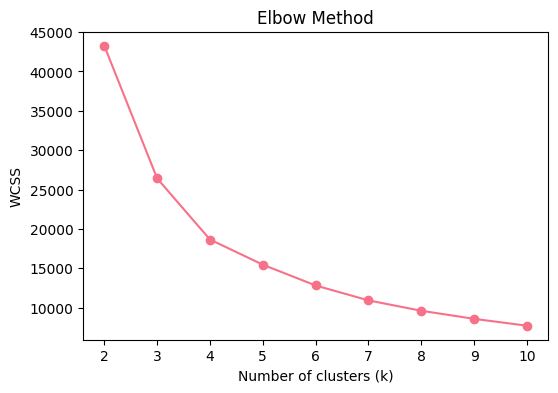

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Test clusters from 2 to 10
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

# Plot WCSS vs k
plt.figure(figsize=(6,4))
plt.plot(range(2, 11), wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [18]:
from sklearn.cluster import KMeans

# Suppose Elbow suggested k=4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)

# Fit KMeans on PCA-transformed data
clusters = kmeans.fit_predict(X_pca)

# Add cluster labels to original dataframe
df["Cluster"] = clusters


c:\Users\Heka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [21]:

cluster_summary = df.groupby("Cluster").mean(numeric_only=True).round(2)
cluster_summary


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,254.27,0.73,432.01,138.74,293.78,20.47,0.54,0.07,0.45,0.01,0.09,8.47,3160.58,641.90,277.31,0.26,11.41
1,2031.44,0.90,34.30,19.71,14.63,1895.15,0.05,0.01,0.03,0.28,6.34,0.61,3807.43,1517.03,964.73,0.04,11.23
2,1366.99,0.97,2667.09,1709.88,957.61,33.30,0.84,0.52,0.59,0.01,0.12,35.18,5931.24,2580.48,812.48,0.25,11.87
3,3367.17,0.98,1327.53,813.81,513.93,2451.90,0.63,0.30,0.43,0.31,8.02,20.61,5994.88,2858.42,1729.77,0.03,11.68


In [22]:

from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_pca, clusters)

print(f"✅ K-Means Results:")
print(f"Number of clusters: {k}")
print(f"Silhouette score: {sil_score:.3f}")
print(f"\nCluster sizes:")
unique, counts = np.unique(clusters, return_counts=True)
for i, count in zip(unique, counts):
    print(f"Cluster {i}: {count} customers ({count/len(clusters)*100:.1f}%)")


✅ K-Means Results:
Number of clusters: 4
Silhouette score: 0.444

Cluster sizes:
Cluster 0: 2804 customers (31.3%)
Cluster 1: 2446 customers (27.3%)
Cluster 2: 2069 customers (23.1%)
Cluster 3: 1631 customers (18.2%)


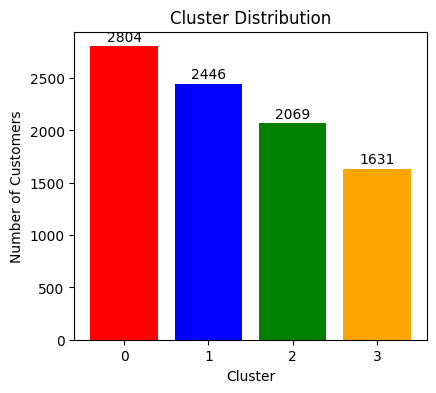

In [23]:
# Simple visualization
plt.figure(figsize=(10, 4))

# Plot 1: Cluster distribution
plt.subplot(1, 2, 1)
plt.bar(unique, counts, color=['red', 'blue', 'green', 'orange'])
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Cluster Distribution')
for i, count in zip(unique, counts):
    plt.text(i, count + 50, str(count), ha='center')


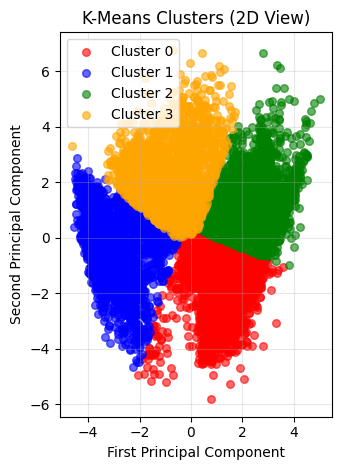


🎯 Simple K-means clustering complete!


In [24]:





# Plot 2: 2D scatter plot
plt.subplot(1, 2, 2)
colors = ['red', 'blue', 'green', 'orange']
for i in range(k):
    mask = clusters == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=colors[i], label=f'Cluster {i}', alpha=0.6, s=30)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('K-Means Clusters (2D View)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🎯 Simple K-means clustering complete!")


In [25]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(X_pca, df['Cluster'])
print(f"Davies-Bouldin Index: {db_score:.3f}")


Davies-Bouldin Index: 0.787


In [26]:
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(X_pca, df['Cluster'])
print(f"Calinski-Harabasz Index: {ch_score:.3f}")


Calinski-Harabasz Index: 9697.082
